<a href="https://colab.research.google.com/github/harleeeen1717/House-Price-Prediction/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving housing.csv to housing.csv


In [4]:
df = pd.read_csv("housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.shape

(545, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [9]:
encoder = LabelEncoder()
categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


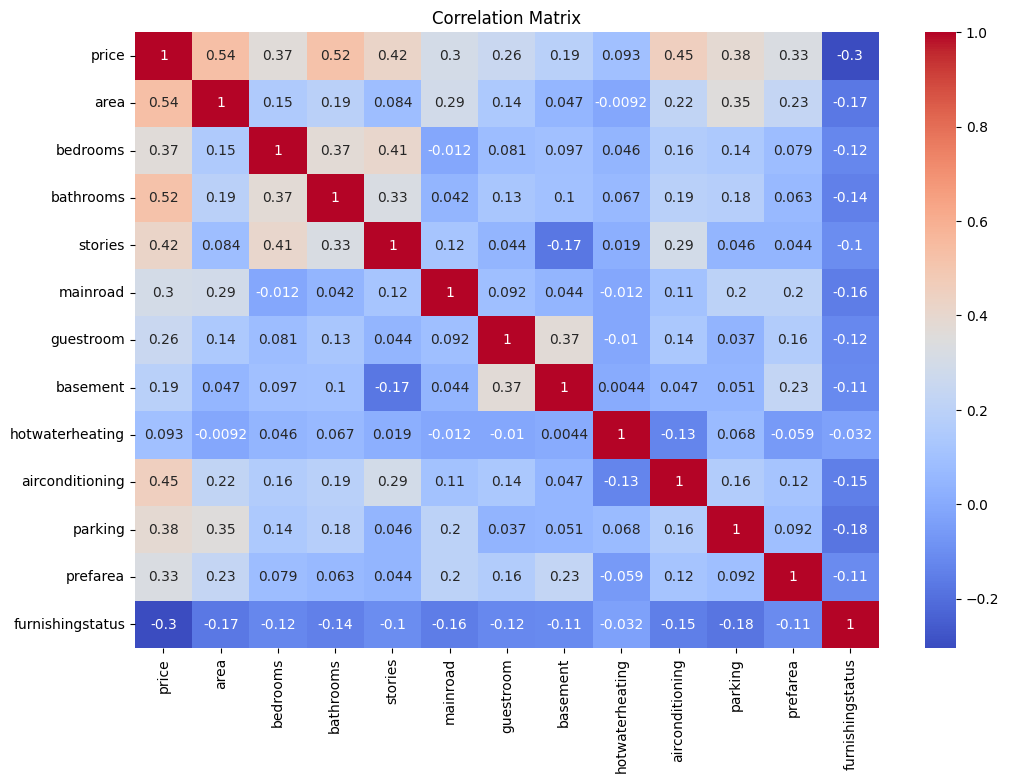

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

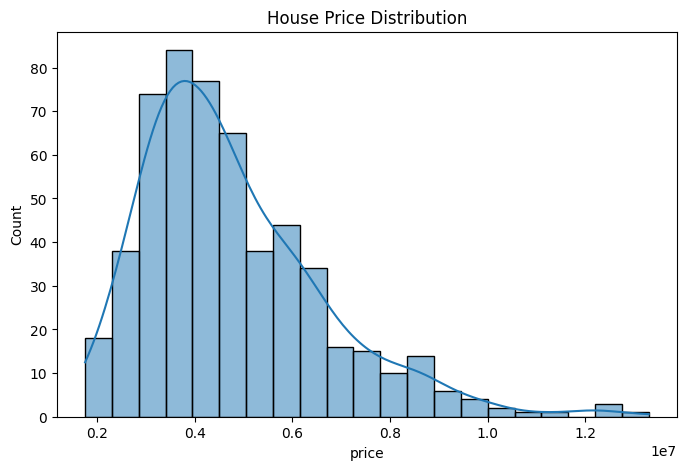

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("House Price Distribution")
plt.show()

In [13]:
X = df.drop("price", axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [15]:
lr_pred = lr.predict(X_test)

In [16]:
print("Linear Regression Results")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression Results
MAE : 979679.6912959901
RMSE : 1331071.4167895108
R2 Score : 0.6494754192267803


In [17]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
rf_pred = rf.predict(X_test)
print("Random Forest Results")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 1025289.6821100918
RMSE : 1401263.0789821919
R2 Score : 0.6115321143409216


In [19]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],
    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})
comparison

,Model,R2 Score
0,Linear Regression,0.649475
1,Random Forest,0.611532


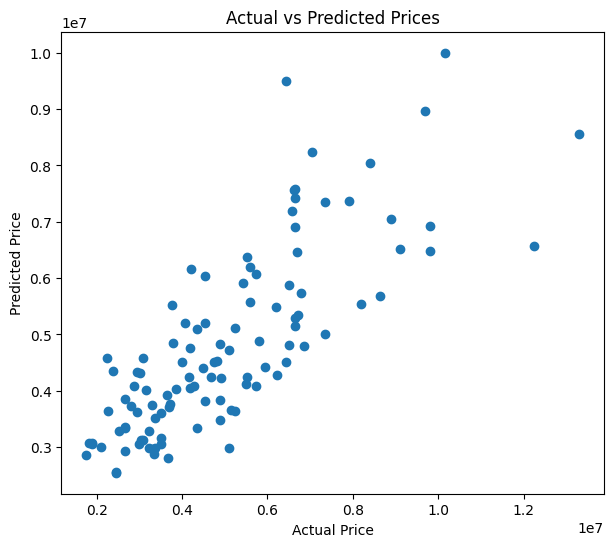

In [20]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

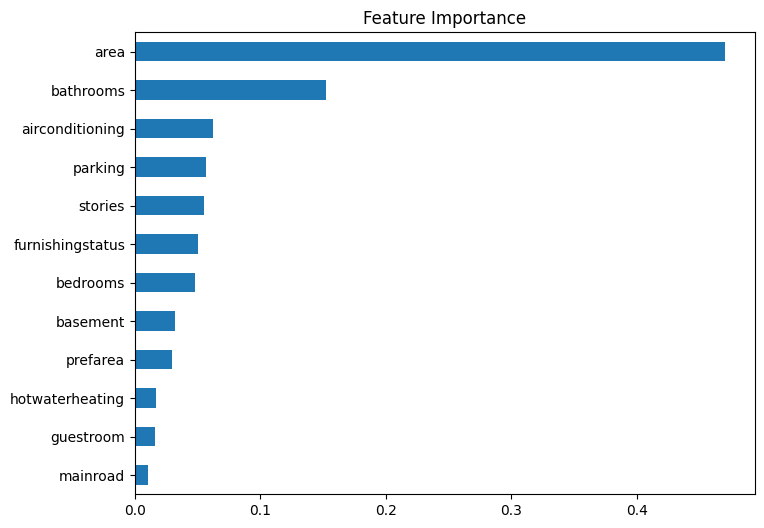

In [21]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

In [22]:
# Conclusion
#This project predicts house prices using machine learning techniques. Two regression models, Linear Regression and Random Forest Regression, were trained and evaluated. Random Forest achieved better performance due to its ability to capture complex relationships in the data.
#This project demonstrates the basic workflow of a machine learning project, including data preprocessing, visualization, model training, evaluation, and prediction.